## Hybrid XGBoost + CNN untuk Deteksi Kecanduan Smartphone

1. Import Library

In [24]:
# Basic Library
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Evaluasi
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# XGBoost
from xgboost import XGBClassifier

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    Conv1D,
    Flatten,
    MaxPooling1D,
    Input
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Ensemble
from sklearn.linear_model import LogisticRegression

2. Load Dataset

In [25]:
# Load dataset
file_path = 'E:\Python - Project\phone-addiction-detection\Data\Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv'

df = pd.read_csv(file_path)

# Lihat data
print(df.head())
print(df.shape)

  transaction_id user_id  age gender  daily_screen_time_hours  \
0       TXN00001  U00001   21   Male                     3.23   
1       TXN00002  U00002   24  Other                     5.09   
2       TXN00003  U00003   31  Other                     6.06   
3       TXN00004  U00004   32  Other                     7.83   
4       TXN00005  U00005   25   Male                     9.96   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                2.01          0.89              4.55         7.55   
1                3.81          2.24              4.44         7.66   
2                1.36          3.83              2.35         4.92   
3                5.85          1.51              3.54         8.23   
4                5.92          3.42              5.27         6.21   

   notifications_per_day  app_opens_per_day  weekend_screen_time stress_level  \
0                    248                154                 3.95       Medium   
1                    127  

3. Data Understanding

In [26]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   str    
 1   user_id                  7500 non-null   str    
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   str    
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   str    
 13  academic_work_impact     7500 non-null   str    
 14  addiction_level          6681 non-n

4.5.6.7. Preprocessing 

⚠️ Sangat penting untuk menghapus fitur yang terlalu berhubungan langsung dengan label.

Contoh leakage:

Addiction_Score

Addiction_Level

Smartphone_Addiction_Result

Label yang dibuat dari scoring

In [27]:
# =========================
# TARGET
# =========================

TARGET = 'addiction_level'

drop_cols = [
    'transaction_id',
    'user_id',
    'addicted_label'
]

# =========================
# HAPUS TARGET NaN
# =========================

df = df.dropna(subset=[TARGET])

# =========================
# FEATURE & TARGET
# =========================

X = df.drop(columns=[TARGET] + drop_cols)

y = df[TARGET]

# =========================
# ENCODE TARGET
# =========================

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(
    y.astype(str)
)

# =========================
# ENCODE FEATURE
# =========================

for col in X.select_dtypes(include='object').columns:
    
    le = LabelEncoder()
    
    X[col] = le.fit_transform(
        X[col].astype(str)
    )

# =========================
# HANDLE MISSING VALUE
# =========================

imputer = SimpleImputer(strategy='most_frequent')

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

# =========================
# FORCE CLEAN NaN
# =========================

X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(0)

# =========================
# CEK FINAL
# =========================

print("TOTAL NaN X:",
      X.isnull().sum().sum())

print("TOTAL NaN y:",
      pd.Series(y).isnull().sum())

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

TOTAL NaN X: 0
TOTAL NaN y: 0
(5344, 12)
(1337, 12)


C:\Users\LENOVO LOQ\AppData\Local\Temp\ipykernel_21244\669779718.py:41: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include='object').columns:


8. Standardisasi

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

9. Reshape untuk CNN

In [29]:
X_train_cnn = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    X_train_scaled.shape[1],
    1
)

X_test_cnn = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)

print(X_train_cnn.shape)
print(X_test_cnn.shape)

(5344, 12, 1)
(1337, 12, 1)


10. Model CNN

In [ ]:
cnn_model = Sequential([
    Input(shape=(X_train_cnn.shape[1], 1)),

    Conv1D(64, kernel_size=2, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=2, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(len(np.unique(y)), activation='softmax')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 11, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 11, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4, 128)         │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,689 (229.25 KB)

 Trainable params: 58,305 (227.75 KB)

 Non-trainable params: 384 (1.50 KB)

11. Training CNN

In [31]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4386 - loss: -228.0323 - val_accuracy: 0.4846 - val_loss: -296.0348
Epoch 2/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4812 - loss: -12374.8301 - val_accuracy: 0.4780 - val_loss: -16950.4062
Epoch 3/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4681 - loss: -91431.1953 - val_accuracy: 0.4818 - val_loss: -126777.0547
Epoch 4/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4653 - loss: -358624.5938 - val_accuracy: 0.4724 - val_loss: -544227.6875
Epoch 5/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4620 - loss: -959837.5625 - val_accuracy: 0.4415 - val_loss: -1507539.3750
Epoch 6/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4568 - loss: -2095660.0000 - val_accuracy: 0.4537 - val_loss: -2884620.7500
Epoch 7/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4571 - loss: -3978080.0000 - val_accuracy: 0.4443 - val_loss: -5396263.5000
Epoch 8/100
134/

12. Model XGBoost

In [32]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

13. Prediksi CNN

In [ ]:
cnn_pred_prob = cnn_model.predict(X_test_cnn).flatten()
cnn_pred_prob = cnn_model.predict(X_test_cnn)

cnn_pred = np.argmax(
    cnn_pred_prob,
    axis=1
)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


14. Prediksi XGBoost

In [34]:
xgb_pred_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]
xgb_pred = xgb_model.predict(X_test_scaled)

15. Hybrid Ensemble (Stacking)

In [35]:
# Gabungkan probabilitas
stack_train = np.column_stack([
    xgb_model.predict_proba(X_train_scaled)[:, 1],
    cnn_model.predict(X_train_cnn).flatten()
])

stack_test = np.column_stack([
    xgb_pred_prob,
    cnn_pred_prob
])

# Meta learner
meta_model = LogisticRegression()
meta_model.fit(stack_train, y_train)

# Final prediction
hybrid_pred = meta_model.predict(stack_test)
hybrid_prob = meta_model.predict_proba(stack_test)[:, 1]

167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


16. Evaluasi XGBoost

=== XGBOOST ===
Accuracy: 0.5684367988032909
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       275
           1       0.50      0.51      0.50       575
           2       0.51      0.48      0.49       487

    accuracy                           0.57      1337
   macro avg       0.60      0.61      0.61      1337
weighted avg       0.57      0.57      0.57      1337



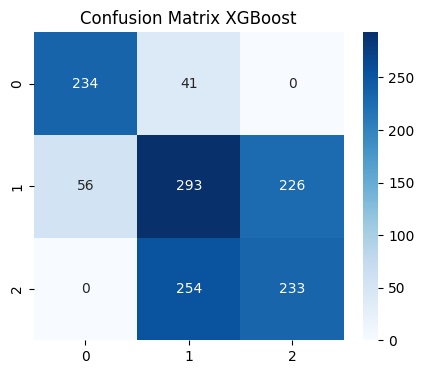

In [36]:
print('=== XGBOOST ===')
print('Accuracy:', accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix XGBoost')
plt.show()

17. Evaluasi CNN

=== CNN ===
Accuracy: 0.45400149588631267
              precision    recall  f1-score   support

           0       0.90      0.13      0.23       275
           1       0.44      0.99      0.61       575
           2       0.00      0.00      0.00       487

    accuracy                           0.45      1337
   macro avg       0.45      0.37      0.28      1337
weighted avg       0.37      0.45      0.31      1337



c:\Conda\envs\findit\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Conda\envs\findit\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Conda\envs\findit\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


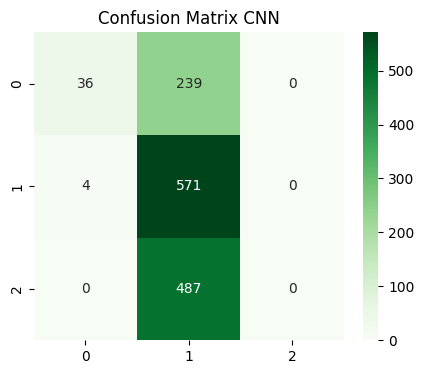

In [37]:
print('=== CNN ===')
print('Accuracy:', accuracy_score(y_test, cnn_pred))
print(classification_report(y_test, cnn_pred))

cm = confusion_matrix(y_test, cnn_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix CNN')
plt.show()

18. Evaluasi Hybrid XGBoost + CNN

In [ ]:
print("=== HYBRID XGBOOST + CNN ===")

print(
    'Accuracy:',
    accuracy_score(y_test, hybrid_pred)
)

print(
    'ROC AUC:',
    roc_auc_score(
        y_test,
        meta_model.predict_proba(stack_test),
        multi_class='ovr'
    )
)

print(
    classification_report(
        y_test,
        hybrid_pred
    )
)

cm = confusion_matrix(
    y_test,
    hybrid_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title('Confusion Matrix Hybrid')

plt.show()

=== HYBRID XGBOOST + CNN ===
Accuracy: 0.5168287210172027


ValueError: multi_class must be in ('ovo', 'ovr')

19. Visualisasi Training CNN

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

20. Feature Importance XGBoost

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(15), x='Importance', y='Feature')
plt.title('Top 15 Feature Importance')
plt.show()